# Sionna 패시브 레이더 드론 탐지 — 결과 리포트

*자동 생성: `build_report.py` · 그림은 노트북에 내장(base64)되어 커널 없이 바로 보입니다.*

Wi-Fi / LTE / 5G 통신 신호를 조명원으로 쓰는 패시브 레이더로 드론을 탐지하고, **reference 구조(파일럿 밀도)** 축에서 세 대역을 *공정하게* 비교한다.

**파이프라인:** TX(조명원) + 감시 RX + 이동 드론(scatterer) → Sionna RT 채널(시변 CIR, bulk Doppler) → 조명 파형 합성 → 정적 클러터 제거 → **CAF**(batches: fast-time 상관=range, slow-time FFT=Doppler) → **CA-CFAR**. *scope: bulk Doppler만, 프로펠러 micro-Doppler 제외.*

## 0. 실험 구성 시각화 — bistatic / open-field geometry

*(`visualize_scene.py`로 생성. "패시브 센싱의 bistatic 세팅·환경이 공간상 어떻게 놓여 있나"를 보기 위한 섹션.)*

**"챔버"가 아니라 open-field bistatic 입니다.** 프로젝트는 무반사실(chamber) 우선에서 **Sionna 시뮬 + 야외 실측**으로 피벗했습니다(PROJECT_CONTEXT §2). 따라서 현재 Sionna 씬에는 **벽이 없습니다** — 빈 자유공간 + 120×120 m 콘크리트 지면(유일한 클러터) + 금속 큐브(드론 대용) + 등방·수직편파 TX/RX 안테나 2개뿐. "챔버처럼 통제됨"이란 *물리적 챔버*가 아니라 **기하·궤적·예산을 고정한 control protocol**(공정성)을 뜻합니다.

**Bistatic 세팅:** 조명원(TX=gNB/AP)과 감시 수신기(RX)가 **떨어져** 있고(baseline L), 드론은 제3의 위치에서 신호를 산란합니다. 레이더가 보는 두 신호: ① **직접파**(TX→RX, = reference/DPI, 동시에 가장 센 클러터) ② **드론 산란파**(TX→드론→RX). 두 경로의 지연차가 **bistatic range** R_b = R_tx+R_rx−L, 드론 속도의 시선방향 성분이 **bistatic Doppler**.

### (A) Sionna RT가 실제로 trace한 경로
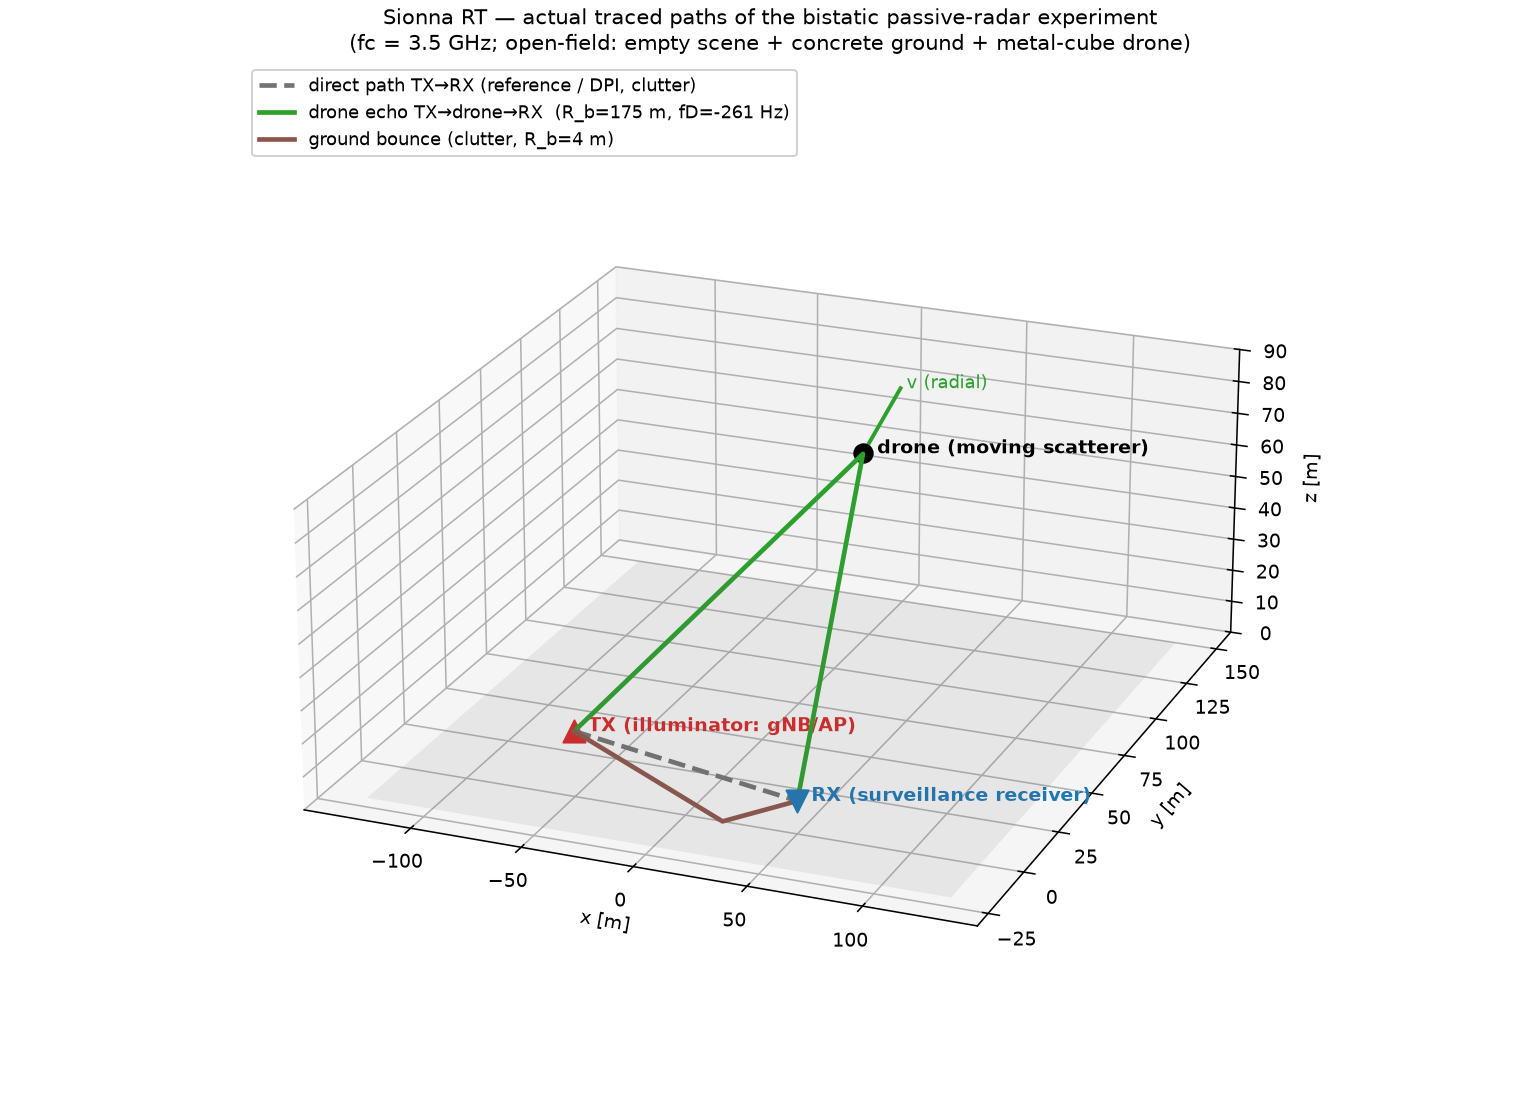

초록=드론 산란파(TX→드론→RX), 회색 점선=직접파(reference/클러터), 갈색=지면 반사(클러터). 드론 경로의 R_b·fD가 곧 RD map에서 드론이 찍히는 셀.

### (B) Bistatic 기하 모식도 — 씬이 어떻게 range-Doppler 셀이 되나
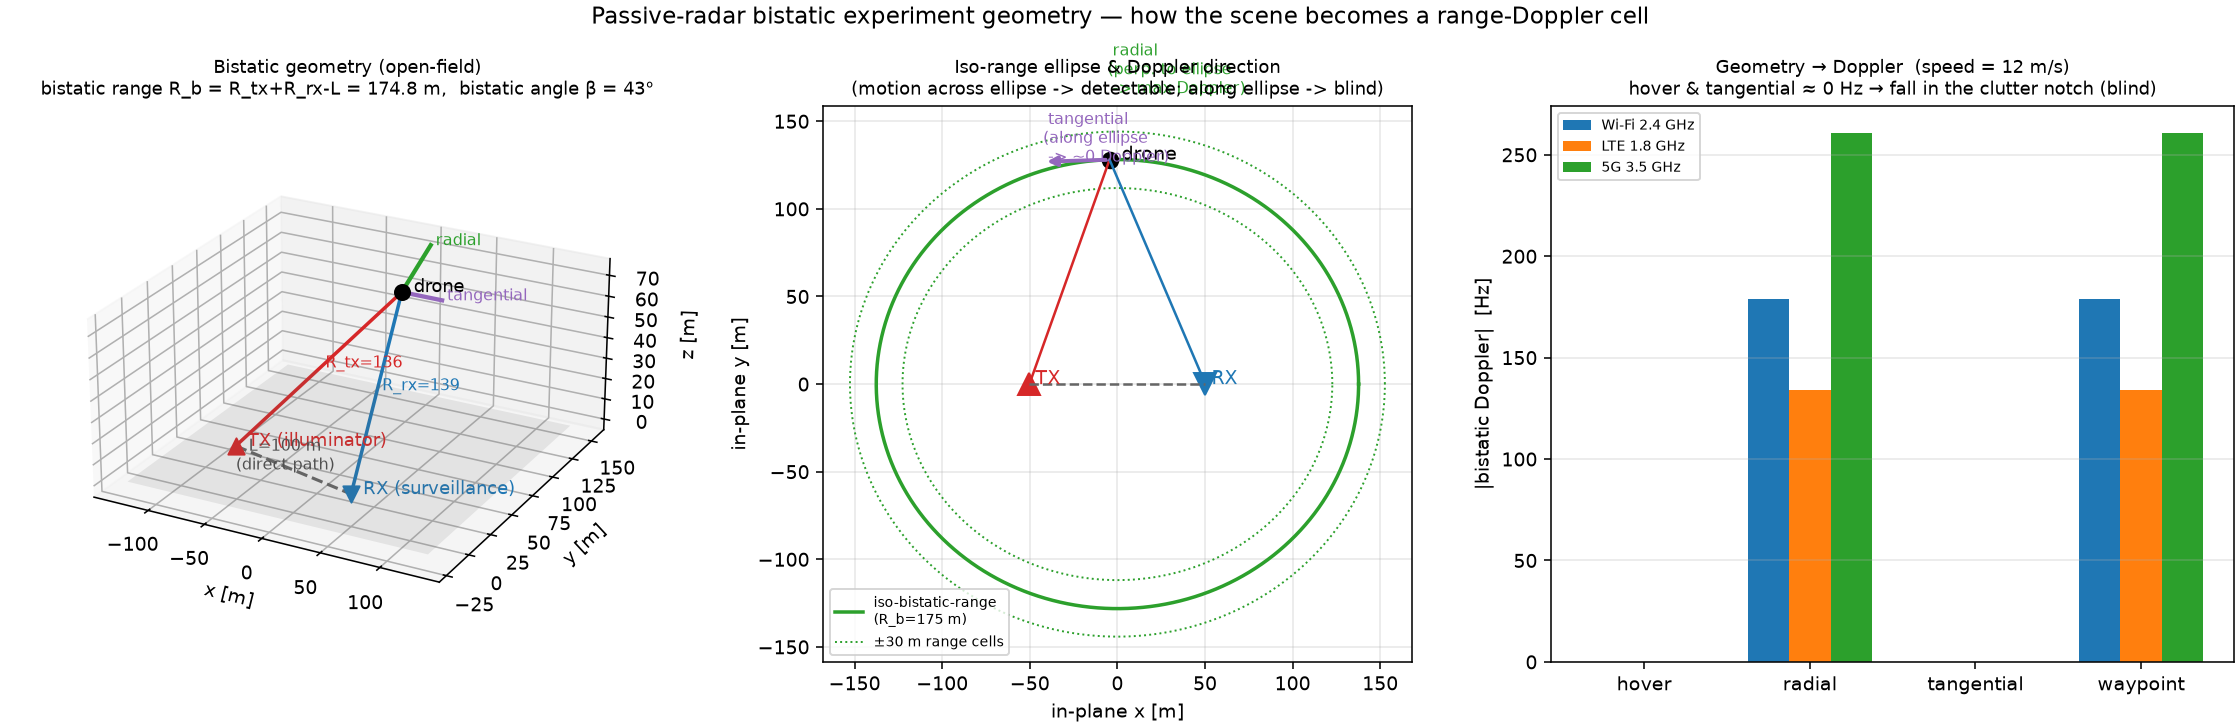

왼쪽: bistatic 삼각형(L, R_tx, R_rx, 각 β). 가운데: **iso-range 타원**(TX·RX를 초점으로 하는 등-bistatic-range 등고선; range 셀 = 두 타원 사이 얇은 껍질). 오른쪽: 시나리오×반송파별 Doppler — **radial은 타원을 가로질러(⟂) 최대 Doppler, tangential/hover는 타원을 따라(∥) ≈0 Hz → 클러터 notch에 묻혀 blind.** 이게 'hover/tangential blind'의 기하학적 이유.

### (C) Sionna 네이티브 씬 렌더 (참고)
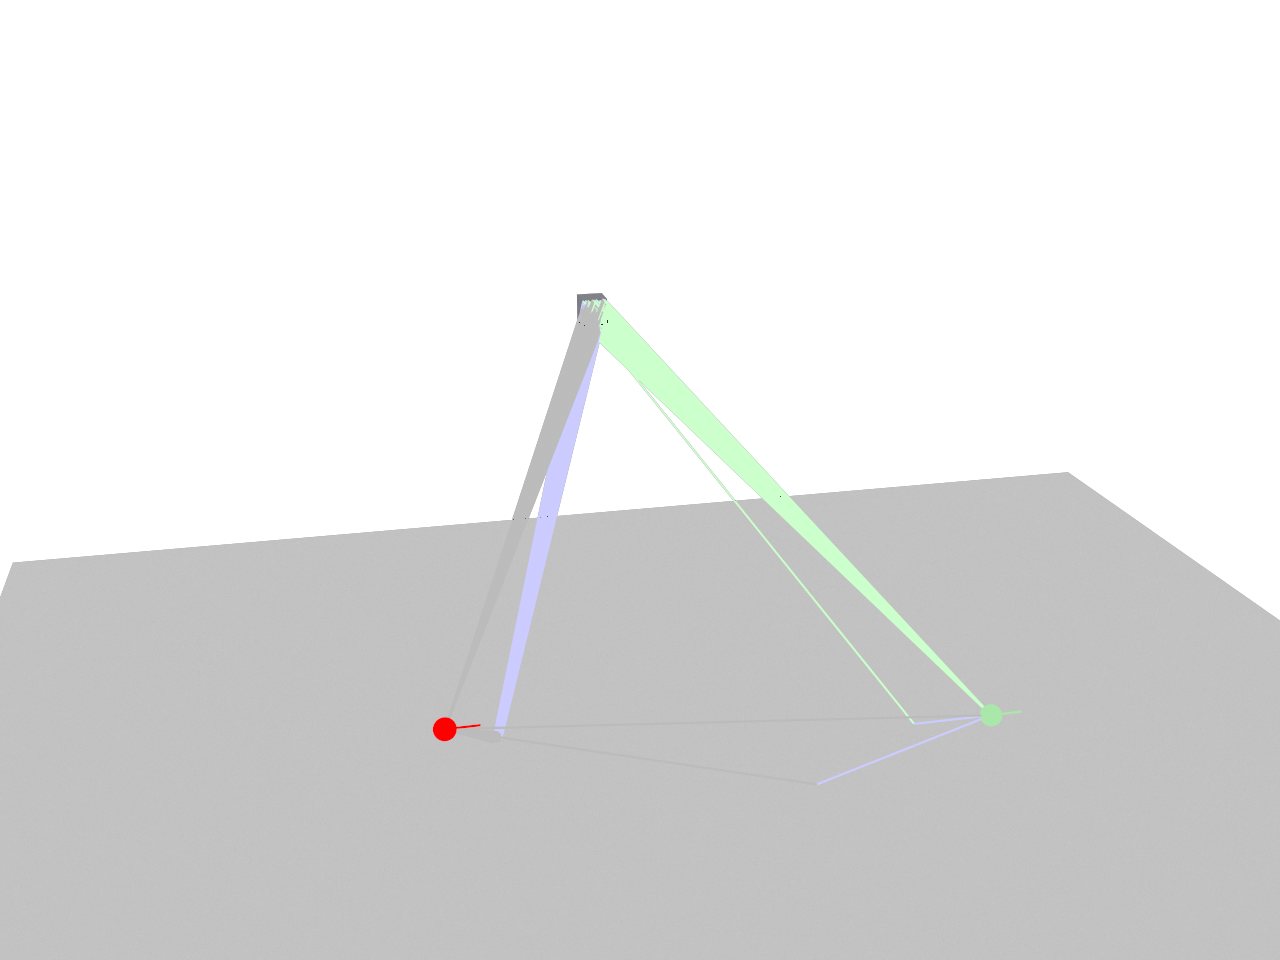

_빨간 ▲=TX, 파란 ▼=RX, 큐브=드론(가시화 위해 마커 확대; 실제 0.3 m·해석적 GT 불변). 선=실제 ray. top/side 뷰는 `outputs/viz_scene_top.png`·`viz_scene_side.png`._

## 1. Phase-1 — controlled 3-axis benchmark (현재 메인)

통제된(open-field, 챔버 아님 — §0) 시뮬에서 **외부 조건(기하·조명·노이즈·적분시간·CFAR) 고정**, 세 축만 본다: **(A) 신호 스펙**, **(B) 드론 RCS**, **(C) 모션 시나리오**. **SCR은 set이 아니라 측정** — 스펙/RCS/모션에서 *나온다*. 고정 예산(직렬화됨): snr_ref=-9.0 dB, CPI=100 ms, trials=24, Pfa=1e-05, hit_tol=30.0 m, anchor RT spread=0.06 dB (5 seeds).

### 헤드라인 (정직·식별가능) — 단일변수 분리 sweep

메인 matrix는 표준=reference구조=반송파가 **collinear**(wifi→preamble·저대역, 5g→SSB·고대역)이라, 거기서 *단일요인* 'carrier가 지배한다'는 **식별 불가능**(교란). 그래서 각 인자를 **하나씩** 분리해 다시 돌렸다(나머지 둘 고정):

| 분리한 인자 | ΔSCR (다른 둘 고정) |
|---|--:|
| reference 구조(밀도, SSB→DMRS) | **11.1 dB** |
| 반송파 fc — 순수 전파(λ², 1.8→5.0 GHz) | **7.0 dB** |
| 반송파 fc — net(+C-band RCS 상승) | 5.2 dB |
| 대역폭 B (band-filling reference=CRS) | 1.3 dB (무관) |
| 대역폭 B (fixed-block reference=SSB) | 7.8 dB (희박화) |

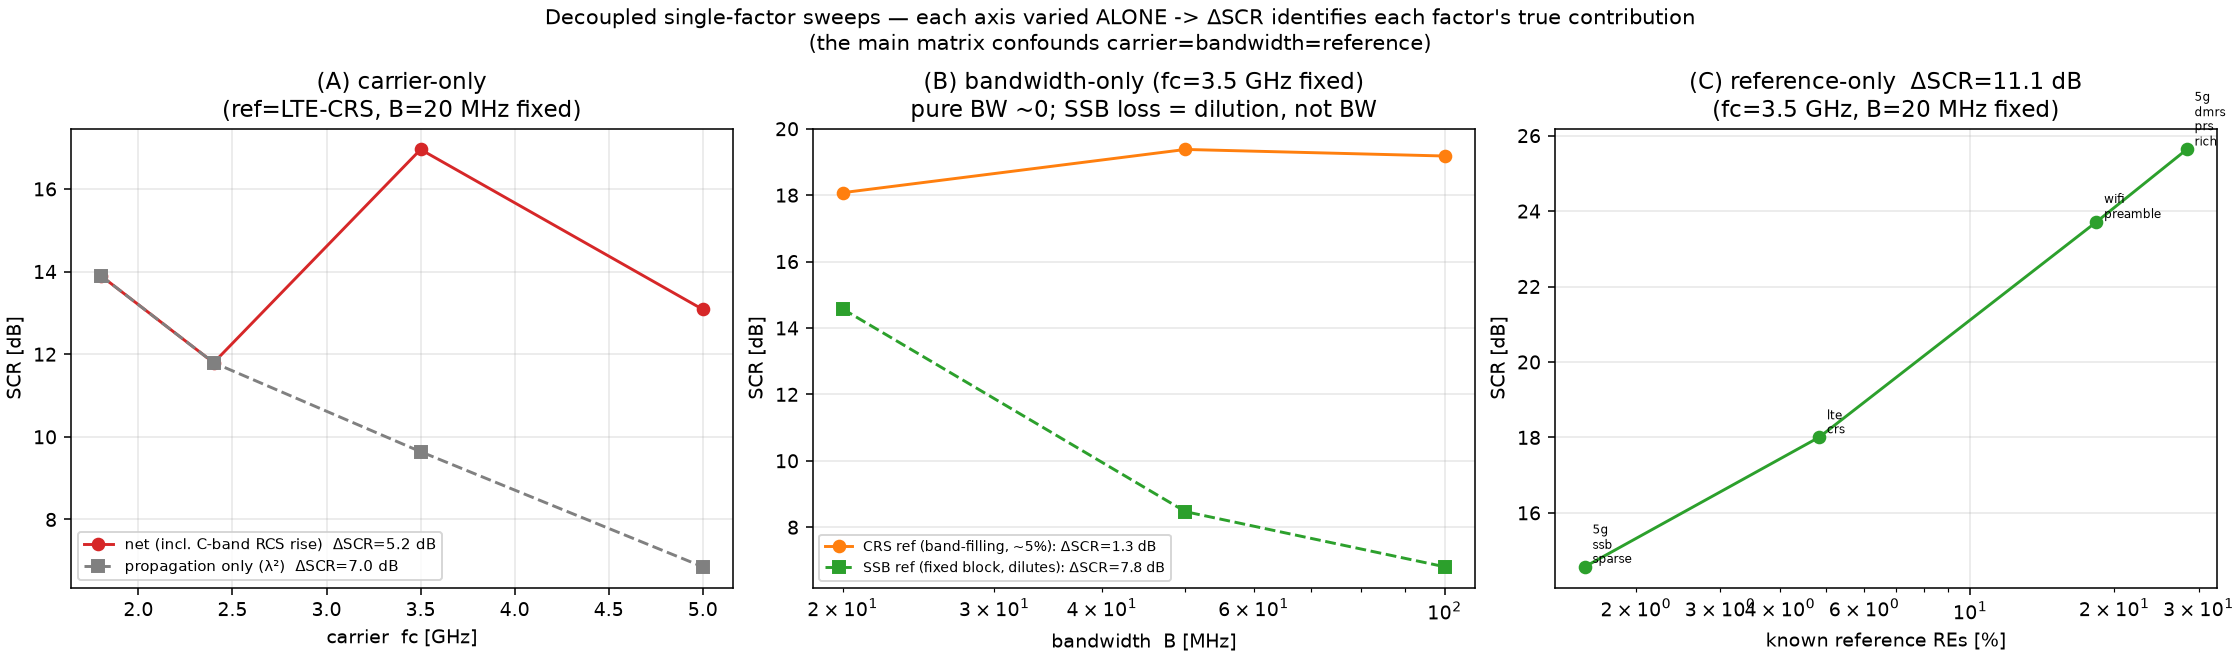

→ **결론(정직·식별가능):** 분리해보면 영향력 순서는 **reference 구조 sparsity** ΔSCR≈11 dB, **반송파 fc (λ² 전파, 1.8→5.0 GHz)** ΔSCR≈7 dB, **대역폭 B (20→100 MHz)** ΔSCR≈1 dB. 즉 **reference 구조가 가장 큰 레버(ΔSCR≈11 dB)**, 그 다음이 **반송파 순수 전파(λ², ≈7 dB)**, **대역폭은 거의 무관(≈1 dB)**. 게다가 실제 드론 RCS는 C-band에서 +8 dB 올라 반송파 path-loss를 상당 부분 상쇄 → **net 반송파 효과는 ΔSCR≈5 dB로 더 작다**(반송파 prop-only 곡선은 단조 감소, net 곡선은 3.5 GHz에서 오히려 반등).

따라서 메인 matrix가 'carrier 단독 지배'로 본 저대역-Wi-Fi vs 고대역-5G의 SCR 격차는 **대부분 reference sparsity(preamble 18% vs SSB 0.2%)**이고 반송파는 보조이며 대역폭은 무관 — std=reference=carrier가 collinear라 carrier 하나로 귀속한 게 **교란**이었다. 실제로 carrier-RCS 보정 후 메인 matrix에선 고대역 셀(wifi 80@5.0, 5g 20@3.5)도 대부분 탐지된다(5g 100@3.5만 실패). 정직한 헤드라인: *시스템으로서* 저대역 Wi-Fi 조명원이 5G를 이기지만 그건 **주로 reference 구조** 덕분(반송파 보조, 대역폭 아님).

⚠️ **대역폭 단서(조건부):** '대역폭 무관(≈1 dB)'은 **밴드를 채우는 reference**(CRS/preamble, 밀도가 대역폭 불변)에서만 성립한다. **SSB는 고정 240-SC 블록**이라 대역폭이 넓어지면 밴드의 더 작은 비율만 덮어 **밀도가 희박해진다**(20MHz 1.56% → 100MHz 0.20%). 그래서 같은 SSB로 대역폭만 늘리면 SCR이 ΔSCR≈8 dB 떨어진다 — 즉 매트릭스의 **5g 100MHz 실패는 순수 대역폭이 아니라 SSB 희박화(=reference sparsity)**. 이는 'reference 구조가 지배'를 *더 강화*한다(위 (B) 패널 두 곡선 비교).

### 시나리오 난이도 (bulk Doppler)
| scenario | mean Pd (Mavic) | note |
|---|--:|---|
| hover | 0.00 | degenerate (0-Doppler: echo removed by canceller+notch) |
| radial | 0.83 |  |
| tangential | 0.00 | degenerate (0-Doppler: echo removed by canceller+notch) |
| doppler_switch | 0.55 |  |

→ **radial 검출, hover/tangential blind.** 0-Doppler 표적은 **bulk-Doppler scope + 이상적 캔슬러** 둘이 *공동으로* 제거한다(둘 다 정직 귀속) — LIPASE/ONERA 실측 blind zone과 일치하므로 *올바른* 결과. 이 셀들은 드론(RCS)축도 **구조적으로 degenerate**(움직이는 성분이 0이라 RCS가 안 먹음).

### Pd vs 대역폭, 시나리오별 (메인 matrix — *기술적 묘사*, 인과 아님)
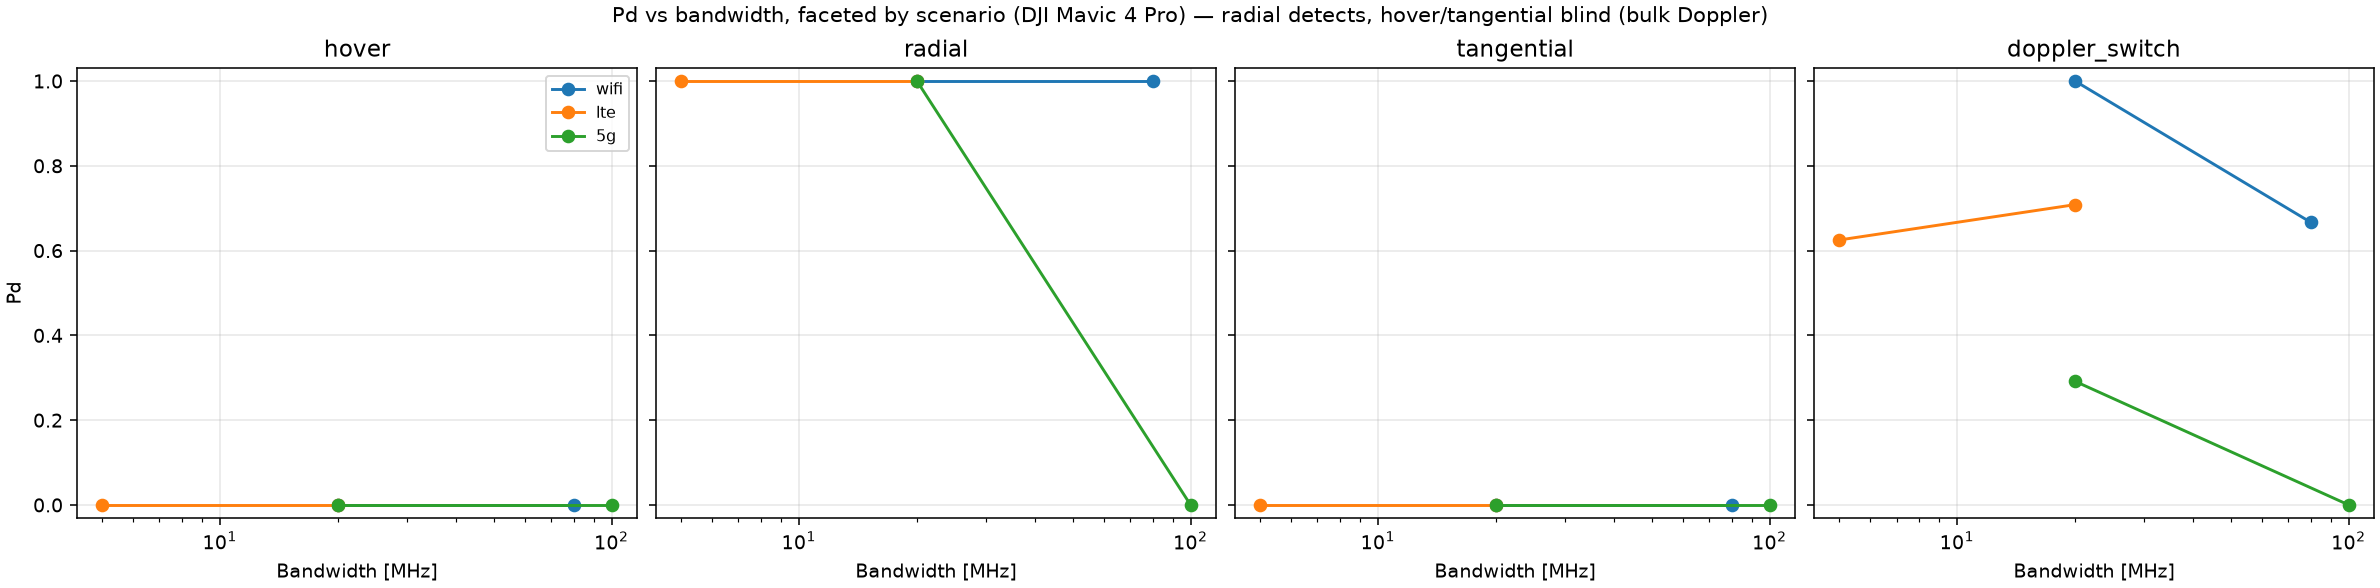

### 시나리오 난이도 & SCR vs 대역폭(radial)
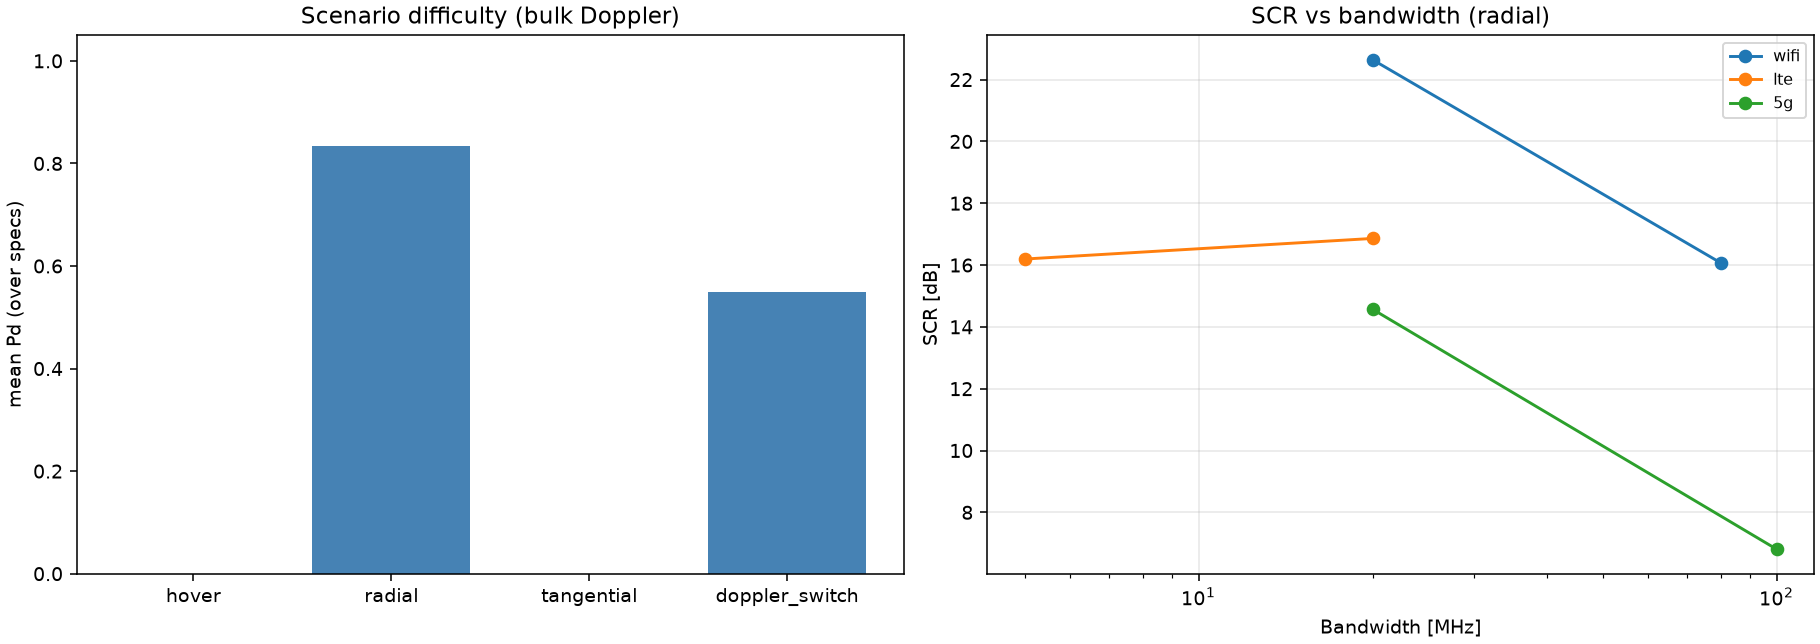

### 기체별 탐지 (RCS = 결정론적 dBsm 추정, fix #4)
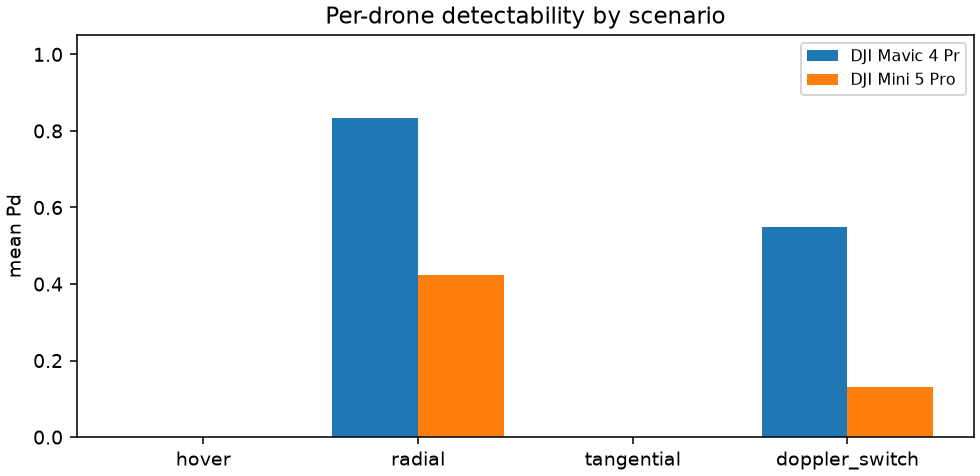

_Pd 허용창은 **미터 고정(±30.0 m)**으로 환산해 대역폭 편향 제거; SCR이 주지표, Pd는 보조. RCS는 추정치(DJI 미공개)·carrier 의존(§drones)._

---
# 이전 단계 (참고) — S2 reference-density 연구 & S1

_아래는 Phase-1 이전의 작업: 파일럿 밀도(reference 구조 sparsity) 4-모드 비교와 S1 단일 RD map. Phase-1(현실 스펙 sweep)이 이를 대체하지만 primitive·검증은 공유._

## S2 TL;DR

고정 기하: 드론 bistatic R=26.5 m, fD=-165 Hz. 운영점 per-sample SNR=-23.0 dB, CPI=42 ms.

| 모드 | known REs | SCR (dB) | PSLR (dB) | Pd | FAR |
|---|--:|--:|--:|--:|--:|
| Wi-Fi | 18.42% | 22.3±0.4 | 1.0 | 1.00 | 9.7e-06 |
| LTE | 4.77% | 16.6±1.0 | 4.7 | 1.00 | 1.3e-05 |
| 5G-SSB | 0.21% | 5.5±2.3 | -3.7 | 0.00 | 0.0e+00 |
| 5G-rich | 28.51% | 24.4±0.3 | 12.5 | 1.00 | 8.9e-06 |

- **reference 밀도↑ → SCR↑ → Pd↑** (단조). 핵심 가설 확인.
- 3/4 모드 **Pd=1.0**, FAR ≈ 설계 Pfa(1e-5). LTE-CRS SCR ≈ 문헌(17.5 dB)과 일치.
- **5G-SSB(0.2% reference)만 실패** — 물리적 바닥(문헌도 'SSB-only는 too sparse').
- Wi-Fi: SCR 높지만 **PSLR 낮음**(프리앰블 주기성 → Doppler 격자엽).

## 2. Stage-1 — 단일 RD map (파이프라인 검증)

단순 씬에서 드론이 **해석적으로 예측한 range-Doppler 셀**에 정확히 잡히고 CFAR가 검출. 왼쪽 raw(직접파/클러터 능선 지배), 오른쪽 클러터 제거 후 드론 피크.

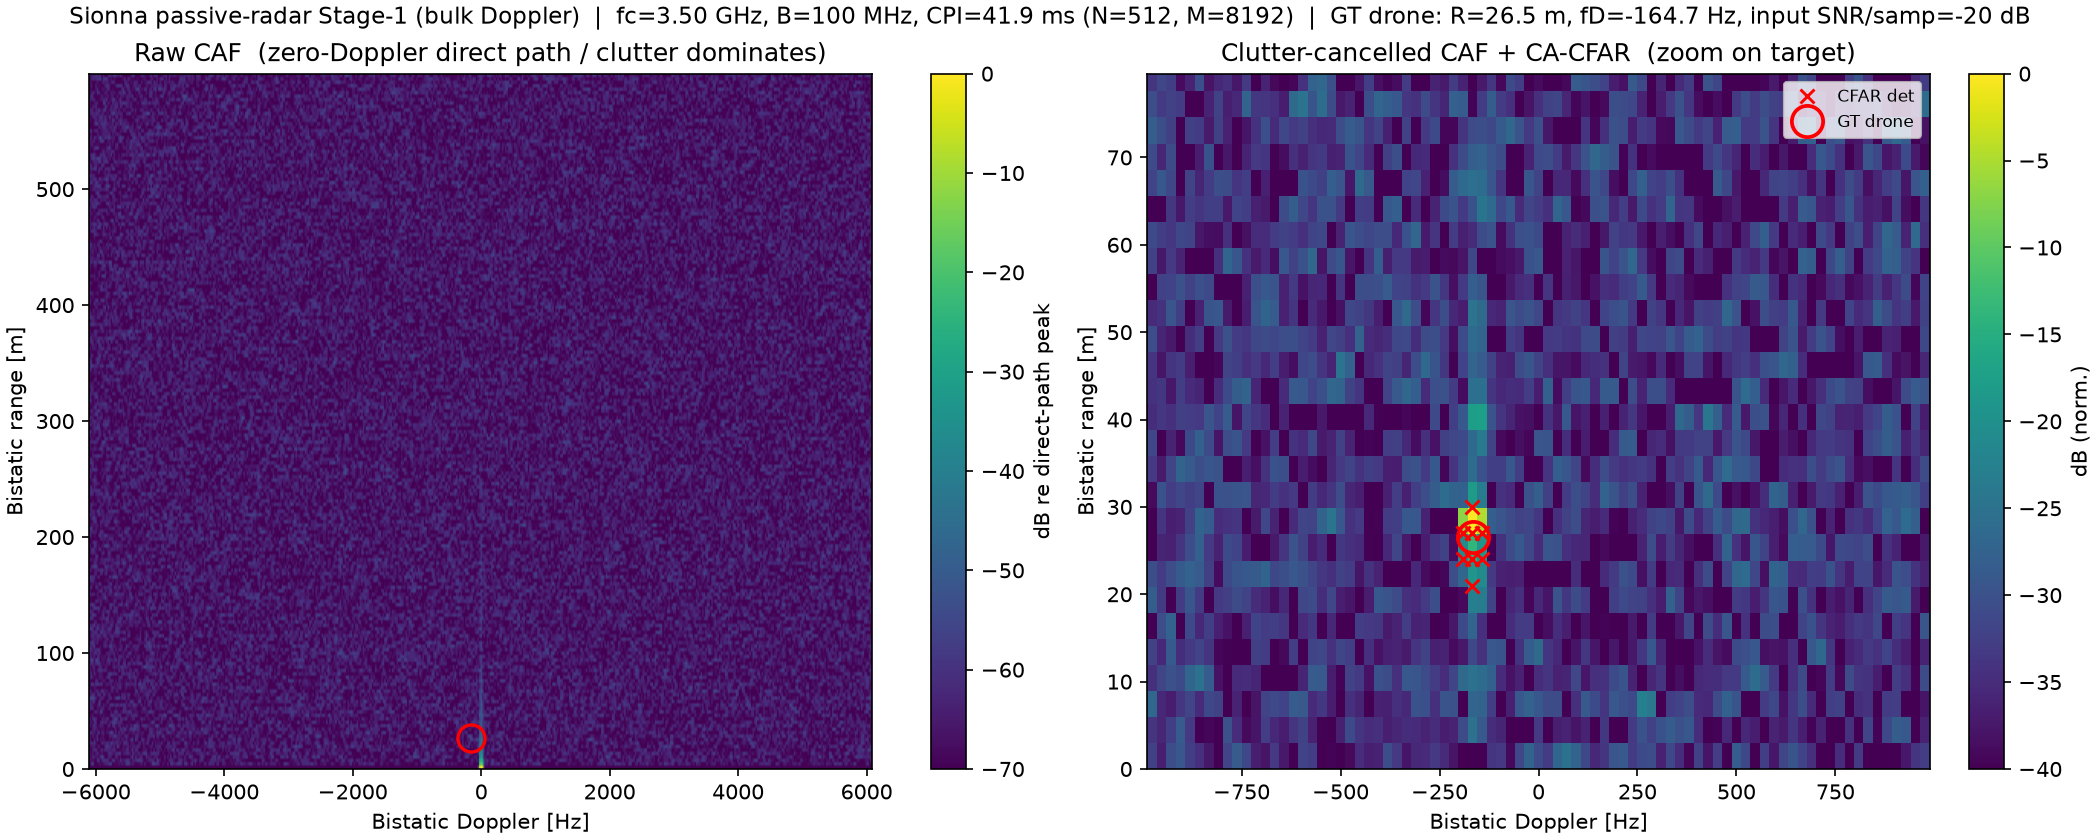

## 3. Stage-2 — 공정 4-모드 벤치마크

동일 OFDM 자원격자에서 **모든 RE를 같은 전력으로 송신**(공정한 조명원), 모드별 **파일럿 마스크**만 다르게 해서 레이더가 *아는* RE를 정함. CAF 레퍼런스는 *아는 파일럿 RE만*으로 재구성 → 마스크가 sparse할수록 이용가능 reference 에너지↓ → 탐지↓. 통제변수: **파일럿 마스크 하나만**.

### per-mode RD map
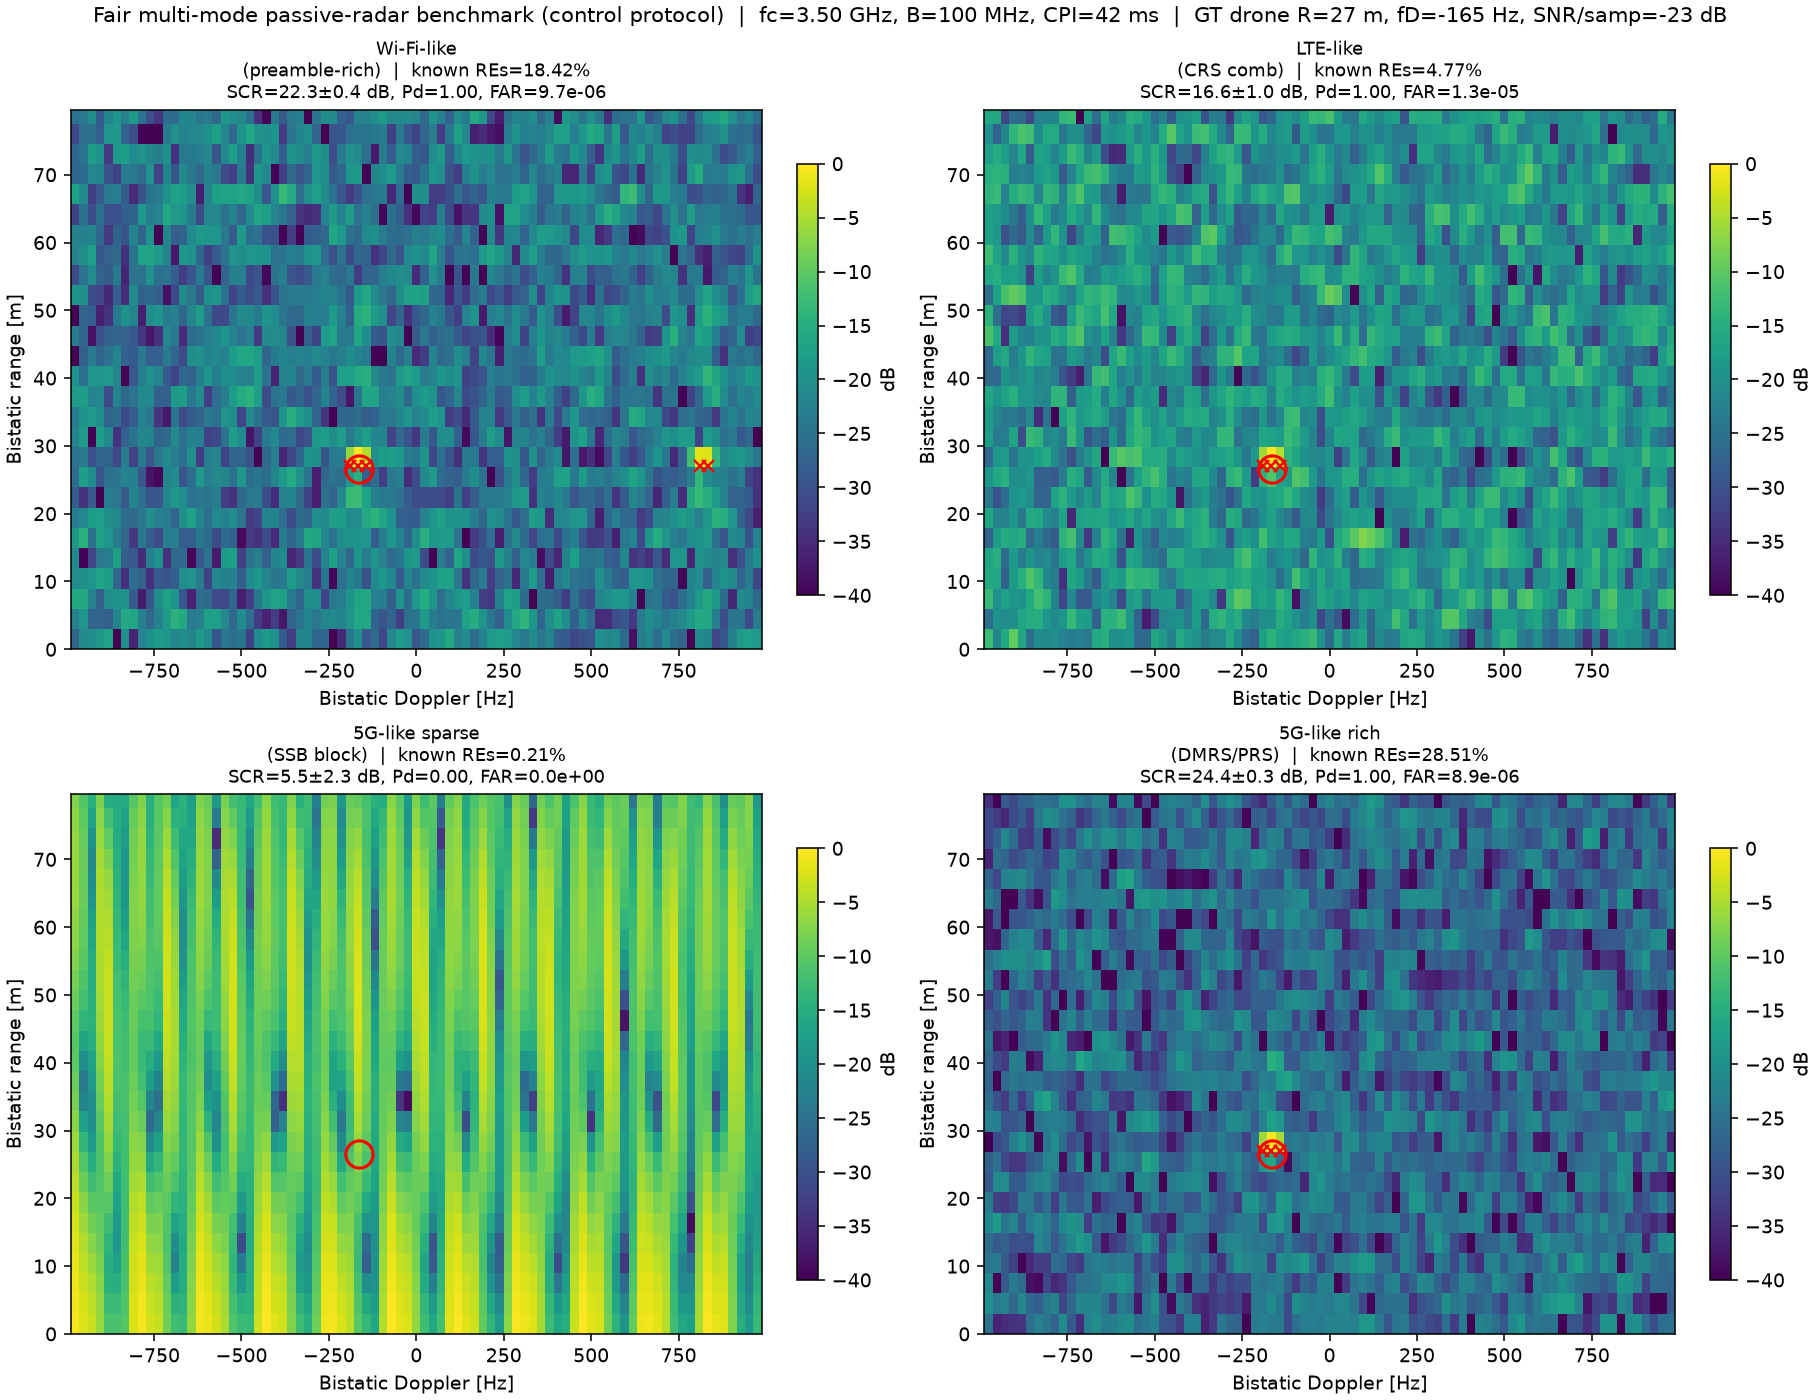

Wi-Fi/LTE/5G-rich는 드론 피크 선명, **5G-SSB는 줄무늬만**(narrowband sparse → range 번짐, 검출 실패). Wi-Fi 패널의 +800 Hz 부근 두 번째 피크 = 프리앰블 주기성에 의한 Doppler 격자엽.

### reference 밀도 vs 성능
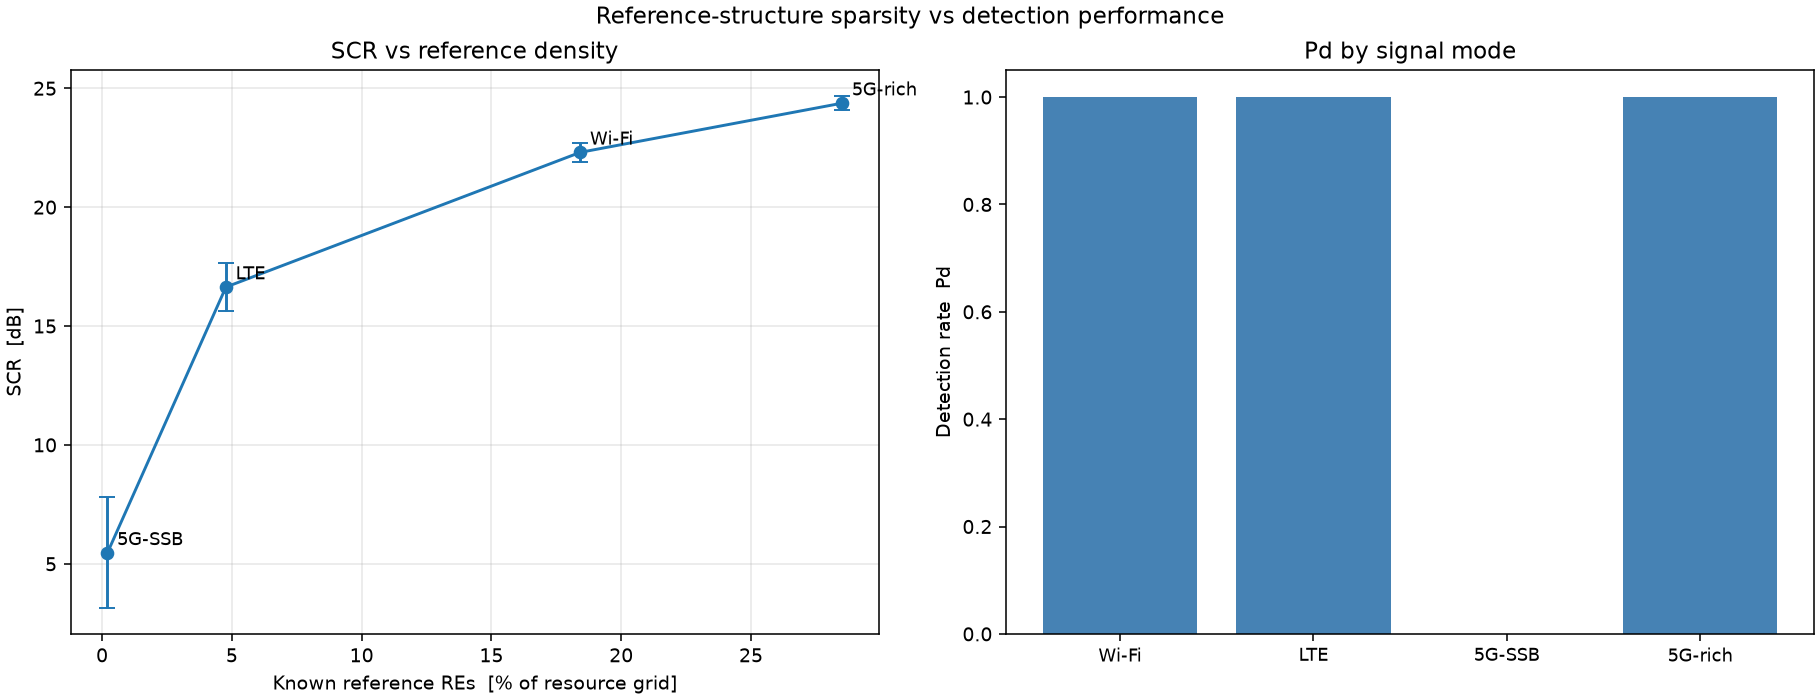

## 4. SNR 스윕 — 모드별 탐지 임계점

운영점(per-sample SNR)을 낮춰가며 Pd 전이를 본다. reference가 풍부할수록 더 낮은 SNR에서 탐지. 5G-rich가 가장 강건, 5G-SSB는 전 구간 실패.

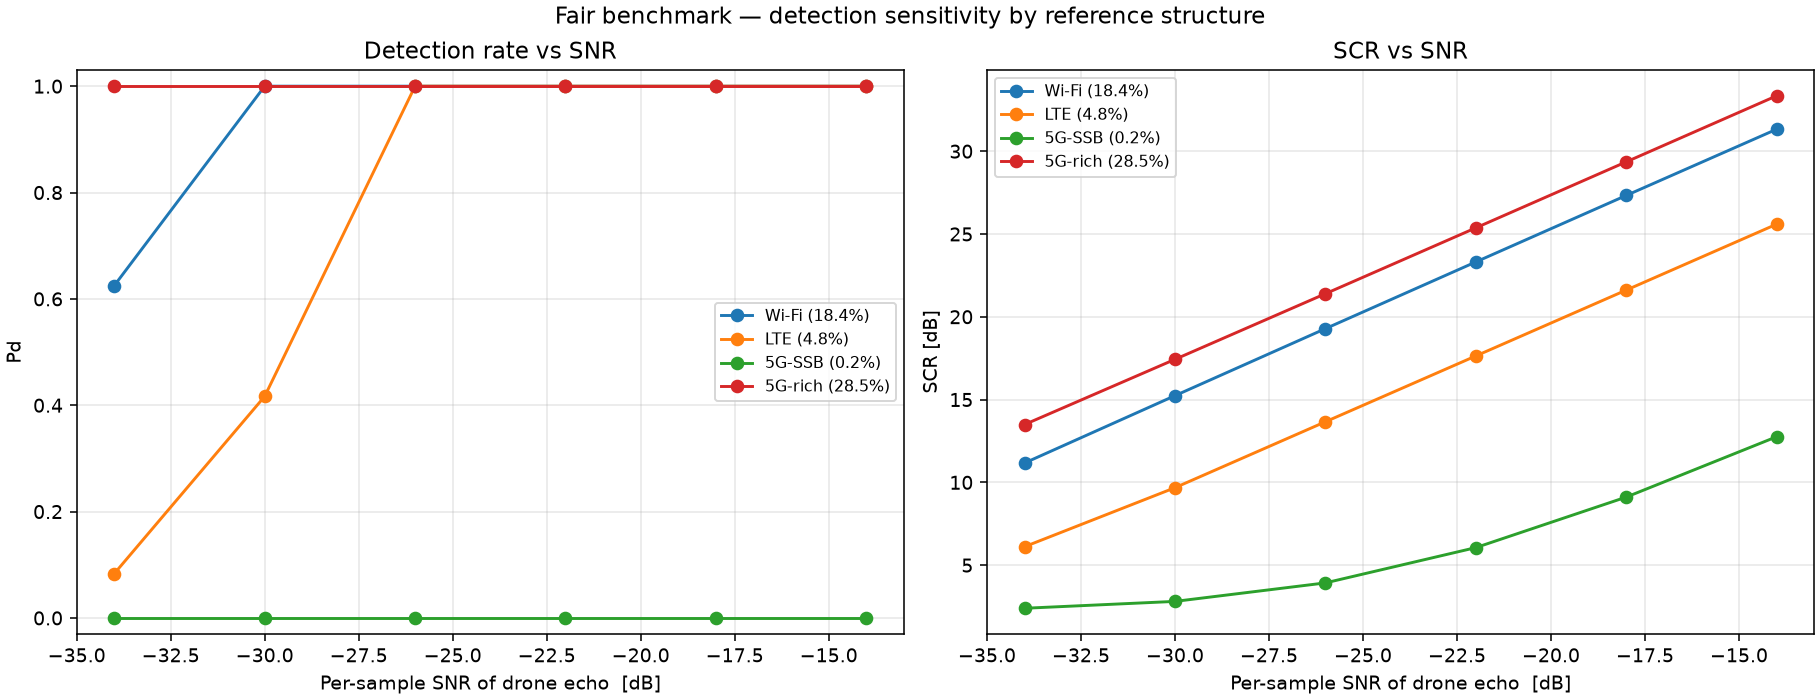

## 5. 기체별 탐지율 (Pd) × 신호 모드

노이즈 바닥을 DJI Mavic 4 Pro @ -23 dB로 고정. RCS는 **결정론적 dBsm 스케일링(fix #4, 고정 ref-mesh)** — 메시 크기로 흉내내던 옛 방식의 비단조성(작은 Mini가 중형 Air3S보다 높게 나오던 문제)을 제거. **RCS는 추정치**(DJI 미공개). bulk Doppler만.

| 기체 | eff SNR | Wi-Fi | LTE | 5G-SSB | 5G-rich |
|---|--:|--:|--:|--:|--:|
| DJI Mini 5 Pro (-24 dBsm) | -29.0 dB | 1.00 | 1.00 | 0.00 | 1.00 |
| DJI Air 3S (-20 dBsm) | -25.0 dB | 1.00 | 1.00 | 0.00 | 1.00 |
| DJI Mavic 4 Pro (-18 dBsm) | -23.0 dB | 1.00 | 1.00 | 0.00 | 1.00 |
| DJI Matrice 4E (-16 dBsm) | -21.1 dB | 1.00 | 1.00 | 0.00 | 1.00 |

- **effSNR이 RCS와 단조**(예): Mini -29 < Air -25 < Mavic -23 < Matrice -21 dB. 큰 RCS → 높은 effSNR → 쉬운 탐지.
- 최난 = **DJI Mini 5 Pro**(최소 RCS), 최이 = **DJI Matrice 4E**(최대 RCS).
- **5G-SSB로는 어떤 기체도 탐지 불가** — reference 바닥이라 RCS로도 못 살림. → procurement(§7)·신호선택 결정에 직결.

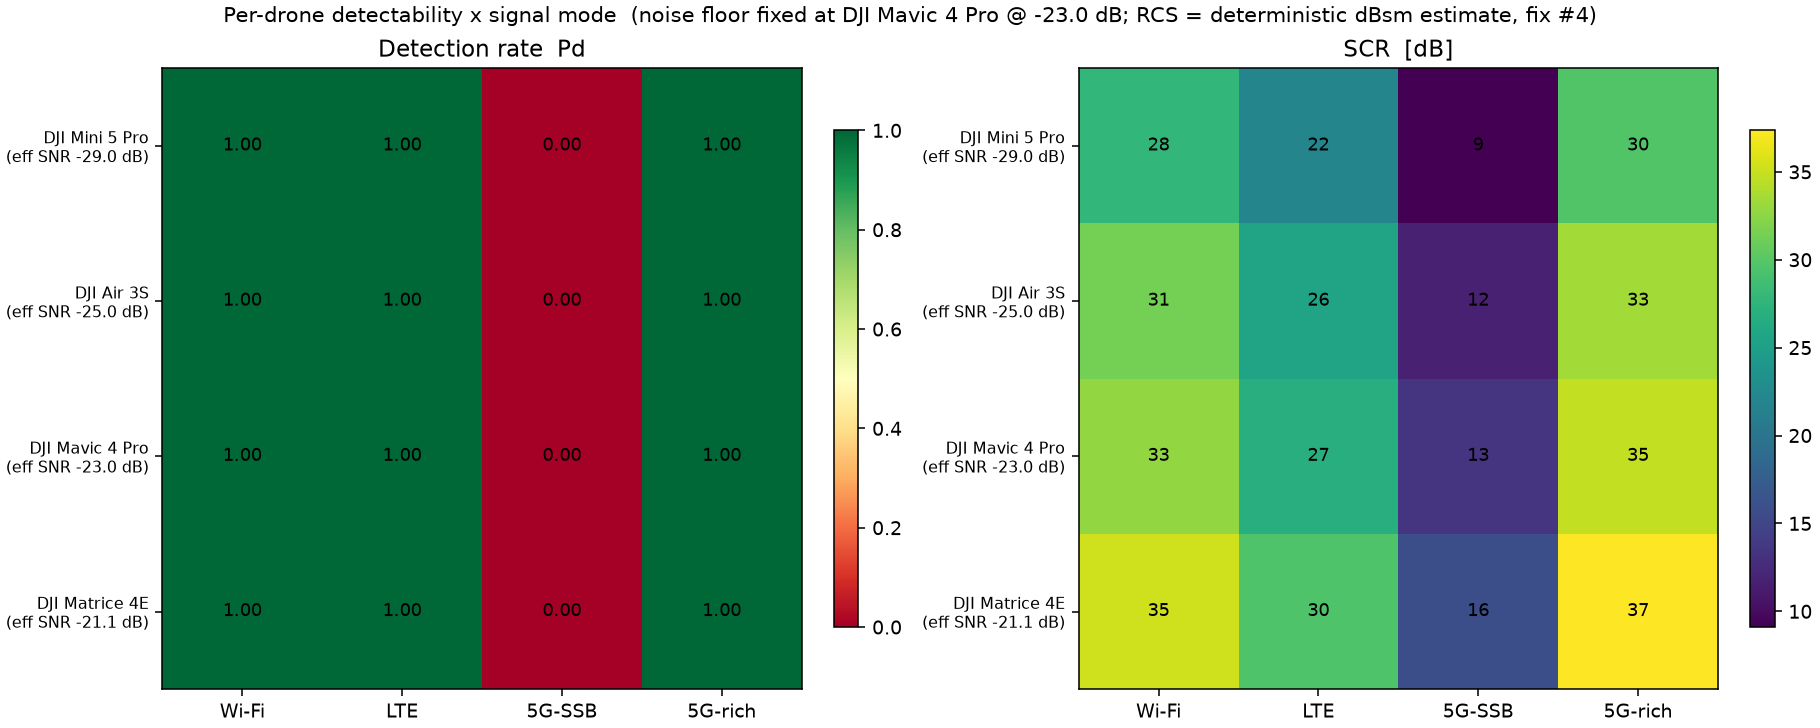

## 6. 성능 레버 실험

“성능이 약해 보인다” → 어디서 회복되는가?

### E1. 적분시간(CPI) 스윕
CPI를 늘리면 처리이득↑ → 약한 모드(LTE)도 회복(Pd 0.38→0.94). 5G 문헌이 SSB를 살리려고 쓰는 적응적/다중블록 적분과 동일한 레버.

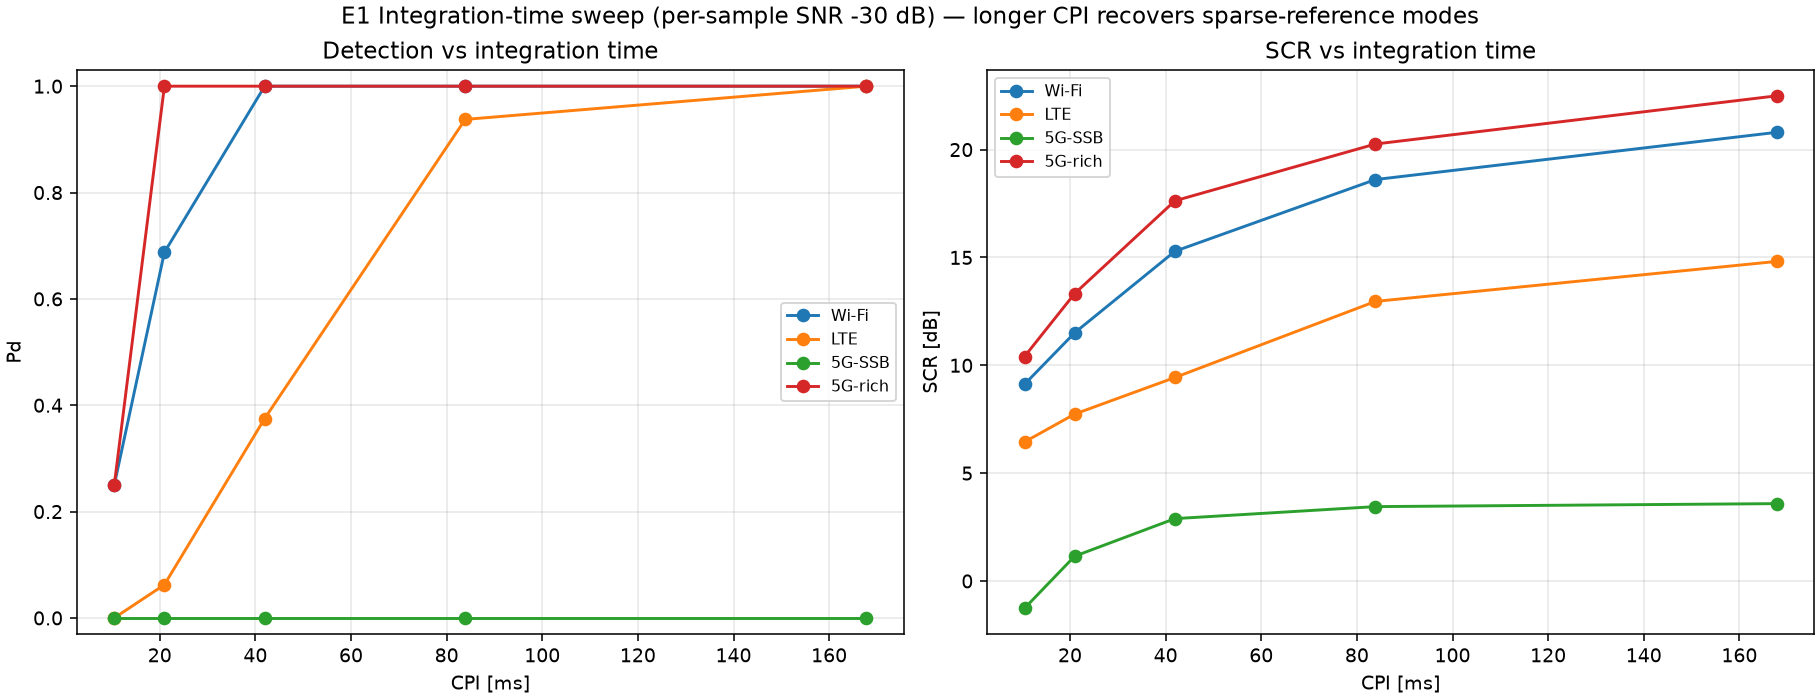

### E2. 레퍼런스 패러다임 (파일럿-only vs 깨끗한 레퍼런스 안테나)
전체 신호를 아는 레퍼런스 안테나면 모든 모드가 강하게 탐지 → '약한 성능'의 정체는 *데이터를 모르는 비용*. 밴드 간 차이는 **파일럿-only** 영역에서만 존재.

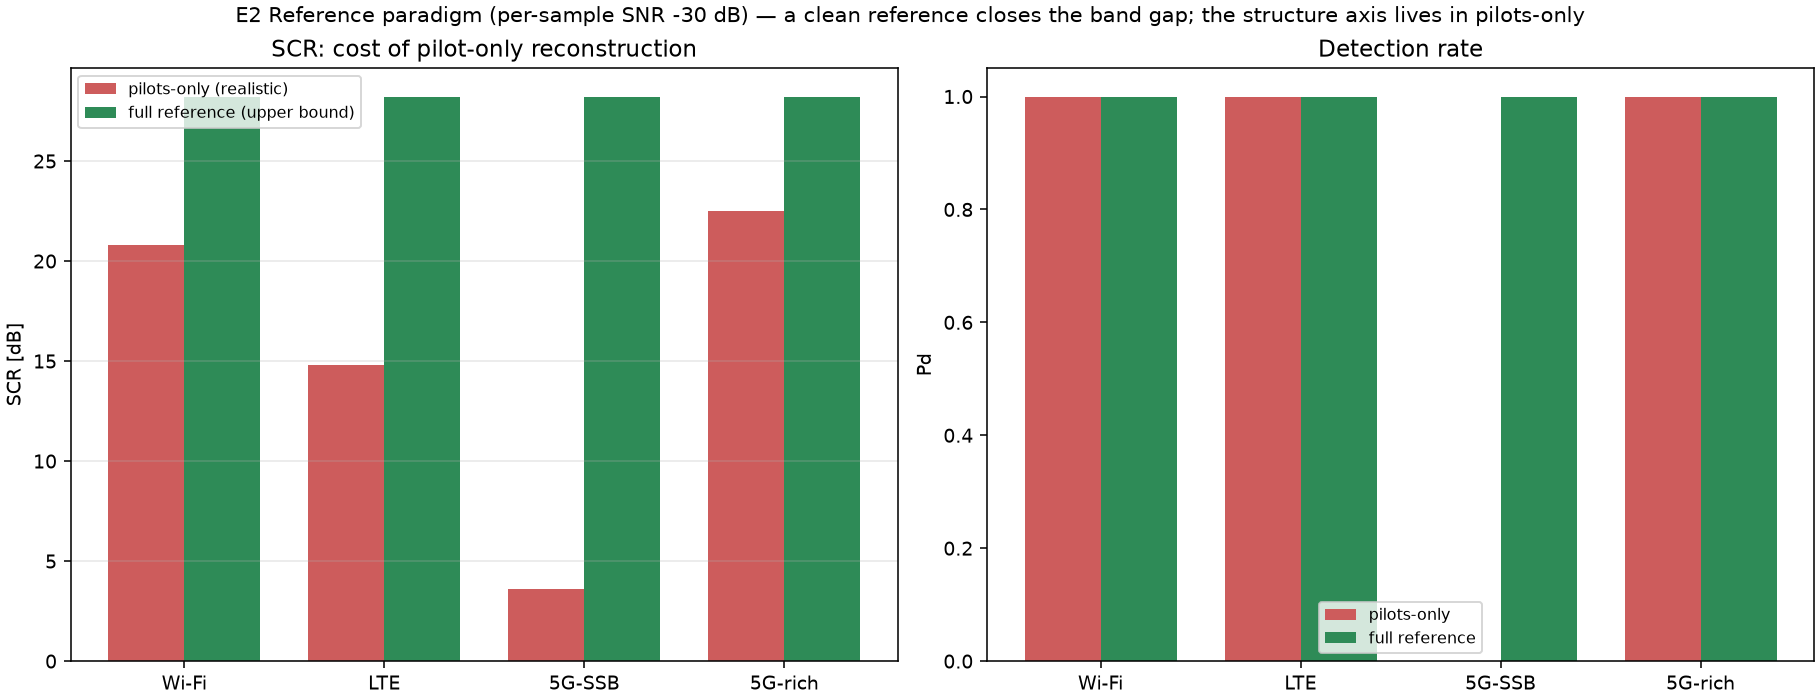

## 7. 정직한 평가 & 다음 단계

**엔진(DSP primitive)은 검증됨:** CAF range가 linear/alias-free, CA-CFAR α가 설계 Pfa와 일치, Doppler 부호 규약 end-to-end 자기일관(Sionna ≈ analytic). 정성 결론(hover/tangential blind, radial 최강, 5G-SSB 바닥, reference 밀도↑→SCR↑)도 robust.

**코드리뷰 반영(이번 라운드):** ① 헤드라인 'carrier dominates'는 collinear 설계의 **교란**이라 버리고 **단일변수 분리 sweep**(§1)으로 교체 — reference sparsity가 주범, 순수 carrier는 ~수 dB. ② Pd 허용창을 **미터 고정**으로 환산(대역폭 편향 제거), SCR 주지표화. ③ compare_drones를 **fix #4(결정론적 dBsm)**로 통일(비단조 제거). ④ RCS를 **calibration placeholder + carrier 의존**으로 정직 라벨. ⑤ hover blind를 **bulk-scope + 캔슬러 공동원인**으로 귀속. ⑥ waypoint→**doppler-switch** 개명. ⑦ N0 **멀티시드**(RT 분산 보고). ⑧ **config 직렬화**(재현성). +위생버그(SNR 표기·notch CFAR·Hann 등).

**한계/주의:** 이상적 클러터 제거(상한선; 실제 ECA는 더 나쁨), RCS는 추정(실측/CAD 필요), numerology는 내부 일관(절대 탐지거리 비교 아님), waypoint는 진짜 궤적이 아닌 Doppler 전환, Monte-Carlo 유한.

**다음:** data-driven ECA-S · 진짜 range-migration 궤적 · 더 큰 grid/trials(tight FAR/CI) · per-drone 운영점 정교화 · (옵션) 프로펠러 micro-Doppler 레이어.

---
코드: `phase1.py`(헤드라인 3축+분리 sweep), `visualize_scene.py`(§0 시각화), `passive_radar_stage1.py`(S1), `passive_radar_s2.py`(S2), `compare_drones.py`+`drones.py`(기체별), `experiments.py`(레버). 결과 JSON/PNG: `outputs/`. 문헌: `docs/LITERATURE_REVIEW.md`·`docs/FINDINGS_S2.md`.